# SpeakShadow - Entrenar con landmarks puros (TCN + Conformer, sin CNN)

Pipeline: en vez de recortes de imagen de la boca, entrena directo con los
landmarks de labios normalizados (posición + velocidad + aceleración) que
genera `extraer_landmarks_npy.py`. Arquitectura **TCN + Conformer**:
convoluciones dilatadas (TCN) para features locales, seguidas de Conformer
(self-attention + módulo convolucional) para relaciones de largo alcance --
la misma familia que usan los modelos VSR de investigación. Clasificación
por Softmax (lista cerrada de frases, no CTC).

1. Comprimí tu carpeta `data/landmarks_npy` (con su `label_map.json` adentro) en un `landmarks_npy.zip` y subilo a tu Google Drive.
2. Entorno de ejecución > Cambiar tipo de entorno > GPU.
3. Corré las celdas en orden.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATASET_PATH = '/content/drive/MyDrive/Aplicaciones_Inteligentes/DATASET/dataset_pt/prueba2_funcional_2.0'  # AJUSTA a donde lo subiste (.zip o carpeta)

import os, shutil, zipfile

if DATASET_PATH.endswith('.zip'):
    os.makedirs('/content/landmarks_npy', exist_ok=True)
    with zipfile.ZipFile(DATASET_PATH) as zf:
        zf.extractall('/content/landmarks_npy')
else:
    shutil.copytree(DATASET_PATH, '/content/landmarks_npy', dirs_exist_ok=True)

# Si el zip tenía una carpeta contenedora (ej. landmarks_npy/landmarks_npy/...),
# bajamos un nivel para encontrar el label_map.json.
root = '/content/landmarks_npy'
if not os.path.exists(os.path.join(root, 'label_map.json')):
    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    for d in subdirs:
        if os.path.exists(os.path.join(root, d, 'label_map.json')):
            root = os.path.join(root, d)
            break

print('Dataset en:', root)

Dataset en: /content/landmarks_npy


In [3]:
import os
import glob
import json
import math
import unicodedata

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

BASE_DIR = '/content'
DATASET_DIR = root
MODEL_PATH = os.path.join(BASE_DIR, 'mejor_modelo_landmarks_conformer.pth')


def _nfc(text):
    return unicodedata.normalize('NFC', text)


class LipReadingDataset(Dataset):
    """Lee landmarks_npy/<palabra>/*.npy y arma (secuencia, label, longitud_real).

    file_paths expl\u00edcito + augment permiten separar train/val sin compartir
    aumento de datos entre ambos splits (augment SOLO en train)."""

    def __init__(self, data_dir, max_frames=60, file_paths=None, augment=False):
        self.data_dir = data_dir
        self.max_frames = max_frames
        self.augment = augment

        label_map_path = os.path.join(data_dir, 'label_map.json')
        with open(label_map_path, 'r', encoding='utf-8') as f:
            raw_label_map = json.load(f)
        self.label_map = {_nfc(w): idx for w, idx in raw_label_map.items()}

        num_classes = max(self.label_map.values()) + 1
        self.class_names = ['?'] * num_classes
        for word, idx in self.label_map.items():
            self.class_names[idx] = word

        if file_paths is not None:
            self.file_paths = list(file_paths)
        else:
            self.file_paths = sorted(glob.glob(os.path.join(data_dir, '*', '*.npy')))
        if not self.file_paths:
            raise RuntimeError(f'No hay archivos .npy en {data_dir}.')

        first_sample = np.load(self.file_paths[0])
        self.landmark_dim = int(first_sample.shape[-1])

    def __len__(self):
        return len(self.file_paths)

    def _label_from_path(self, path):
        word = _nfc(os.path.basename(os.path.dirname(path)))
        return self.label_map[word]

    def _apply_augmentation(self, sequence):
        # Ruido gaussiano leve (simula jitter de detecci\u00f3n). Chico a prop\u00f3sito:
        # la se\u00f1al normalizada ya es peque\u00f1a (std temporal t\u00edpica ~0.02-0.03).
        sequence = sequence + np.random.normal(0, 0.003, sequence.shape).astype(np.float32)

        shift = np.random.uniform(-0.01, 0.01, size=(1, sequence.shape[1])).astype(np.float32)
        scale = np.random.uniform(0.97, 1.03)
        sequence = sequence * scale + shift

        T = sequence.shape[0]
        n_mask = max(1, int(round(T * np.random.uniform(0.08, 0.12))))
        n_mask = min(n_mask, T)
        mask_idx = np.random.choice(T, size=n_mask, replace=False)
        sequence[mask_idx] = 0.0
        return sequence.astype(np.float32)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        sequence = np.load(path).astype(np.float32)
        label = self._label_from_path(path)

        if self.augment:
            sequence = self._apply_augmentation(sequence)

        T = sequence.shape[0]
        if T < self.max_frames:
            pad = np.zeros((self.max_frames - T, sequence.shape[1]), dtype=np.float32)
            sequence = np.concatenate([sequence, pad], axis=0)
            real_length = T
        elif T > self.max_frames:
            sequence = sequence[:self.max_frames]
            real_length = self.max_frames
        else:
            real_length = T

        return (
            torch.from_numpy(sequence),
            torch.tensor(label, dtype=torch.long),
            torch.tensor(real_length, dtype=torch.long),
        )


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TCNBlock(nn.Module):
    """Convoluci\u00f3n 1D dilatada con conexi\u00f3n residual (TCN de Bai et al.)."""

    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        residual = x
        x = x.transpose(1, 2)
        if key_padding_mask is not None:
            x = x.masked_fill(key_padding_mask.unsqueeze(1), 0.0)
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        x = self.bn2(self.conv2(x))
        x = x.transpose(1, 2)
        return self.relu(residual + self.dropout(x))


class TCNFeatureExtractor(nn.Module):
    """Extracci\u00f3n de features locales ANTES del Conformer -- dilataci\u00f3n
    creciente (1, 2, 4...) para agrandar el campo receptivo temporal."""

    def __init__(self, channels, n_blocks=3, kernel_size=3, dropout=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            TCNBlock(channels, kernel_size=kernel_size, dilation=2 ** i, dropout=dropout)
            for i in range(n_blocks)
        ])

    def forward(self, x, key_padding_mask=None):
        for block in self.blocks:
            x = block(x, key_padding_mask=key_padding_mask)
        return x


class ConformerFeedForward(nn.Module):
    def __init__(self, d_model, dim_feedforward, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, dim_feedforward),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class ConformerConvModule(nn.Module):
    def __init__(self, d_model, kernel_size=15, dropout=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(d_model)
        self.pointwise_conv1 = nn.Conv1d(d_model, 2 * d_model, kernel_size=1)
        self.glu = nn.GLU(dim=1)
        padding = (kernel_size - 1) // 2
        self.depthwise_conv = nn.Conv1d(
            d_model, d_model, kernel_size=kernel_size, padding=padding, groups=d_model
        )
        self.batch_norm = nn.BatchNorm1d(d_model)
        self.swish = nn.SiLU()
        self.pointwise_conv2 = nn.Conv1d(d_model, d_model, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        residual = x
        x = self.layer_norm(x)
        x = x.transpose(1, 2)
        if key_padding_mask is not None:
            x = x.masked_fill(key_padding_mask.unsqueeze(1), 0.0)
        x = self.pointwise_conv1(x)
        x = self.glu(x)
        x = self.depthwise_conv(x)
        x = self.batch_norm(x)
        x = self.swish(x)
        x = self.pointwise_conv2(x)
        x = self.dropout(x)
        x = x.transpose(1, 2)
        return residual + x


class ConformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dim_feedforward, conv_kernel_size=15, dropout=0.1):
        super().__init__()
        self.ff1 = ConformerFeedForward(d_model, dim_feedforward, dropout)
        self.self_attn_norm = nn.LayerNorm(d_model)
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.attn_dropout = nn.Dropout(dropout)
        self.conv_module = ConformerConvModule(d_model, conv_kernel_size, dropout)
        self.ff2 = ConformerFeedForward(d_model, dim_feedforward, dropout)
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, x, src_key_padding_mask=None):
        x = x + 0.5 * self.ff1(x)
        residual = x
        x_norm = self.self_attn_norm(x)
        attn_out, _ = self.self_attn(x_norm, x_norm, x_norm, key_padding_mask=src_key_padding_mask, need_weights=False)
        x = residual + self.attn_dropout(attn_out)
        x = self.conv_module(x, key_padding_mask=src_key_padding_mask)
        x = x + 0.5 * self.ff2(x)
        return self.final_norm(x)


class ConformerEncoder(nn.Module):
    def __init__(self, d_model, n_layers, n_heads, dim_feedforward, conv_kernel_size=15, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            ConformerBlock(d_model, n_heads, dim_feedforward, conv_kernel_size, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, src_key_padding_mask=None):
        for layer in self.layers:
            x = layer(x, src_key_padding_mask=src_key_padding_mask)
        return x


def masked_mean_pool(x, src_key_padding_mask):
    """Global Average Pooling que ignora los frames de padding."""
    if src_key_padding_mask is None:
        return x.mean(dim=1)
    real_mask = (~src_key_padding_mask).unsqueeze(-1).float()
    summed = (x * real_mask).sum(dim=1)
    counts = real_mask.sum(dim=1).clamp(min=1.0)
    return summed / counts


class LipReadingConformer(nn.Module):
    # Defaults pensados para dataset CHICO (pocas clases / pocas muestras).
    # Cuando tengas el dataset completo (57 clases, ~500 clips c/u) sub\u00ed
    # hidden_dim=256, n_layers=4, dim_feedforward=512.
    def __init__(self, num_classes, input_dim, hidden_dim=128,
                 n_layers=2, n_heads=8, dim_feedforward=256,
                 conv_kernel_size=15, tcn_blocks=3, tcn_kernel_size=3, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.tcn = TCNFeatureExtractor(hidden_dim, n_blocks=tcn_blocks, kernel_size=tcn_kernel_size, dropout=dropout)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        self.conformer_encoder = ConformerEncoder(
            d_model=hidden_dim, n_layers=n_layers, n_heads=n_heads,
            dim_feedforward=dim_feedforward, conv_kernel_size=conv_kernel_size, dropout=dropout,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, num_classes),
        )

    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x)
        x = self.tcn(x, key_padding_mask=src_key_padding_mask)
        x = self.pos_encoder(x)
        x = self.conformer_encoder(x, src_key_padding_mask=src_key_padding_mask)
        pooled = masked_mean_pool(x, src_key_padding_mask)
        return self.classifier(pooled)


def make_padding_mask(lengths, max_len, device):
    idx = torch.arange(max_len, device=device).unsqueeze(0)
    return idx >= lengths.unsqueeze(1)


def build_warmup_cosine_scheduler(optimizer, epochs, warmup_epochs=5):
    """LR sube gradual las primeras `warmup_epochs` y despu\u00e9s decae en coseno.
    Sin warmup, un Conformer desde cero con LR=1e-3 tiende a desestabilizarse
    en las primeras \u00e9pocas (gradientes grandes contra pesos aleatorios) --
    eso es lo que se vio como Val Loss rebotando sin bajar."""
    warmup_epochs = max(1, min(warmup_epochs, epochs - 1)) if epochs > 1 else 1

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))

    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r--', label='Validation Loss', linewidth=2)
    ax1.set_title('Convergencia de P\u00e9rdida'); ax1.set_xlabel('\u00c9pocas'); ax1.set_ylabel('P\u00e9rdida'); ax1.legend(); ax1.grid(True)
    ax2.plot(epochs, train_accs, 'b-', label='Train Accuracy', linewidth=2)
    ax2.plot(epochs, val_accs, 'g-', label='Validation Accuracy', linewidth=2)
    ax2.set_title('Precisi\u00f3n del Modelo'); ax2.set_xlabel('\u00c9pocas'); ax2.set_ylabel('Precisi\u00f3n (%)'); ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'landmarks_conformer_curvas.png'))
    plt.show()


print('Todo definido (TCN + Conformer + warmup + grad clipping).')

Todo definido (TCN + Conformer + warmup + grad clipping).


Entrenando en: cuda
Clases (20): ['asqueroso', 'camba_de_mierda', 'ciego_de_mierda', 'colla_y_mierda', 'de_esta_no_te_salvas', 'enano', 'engendro', 'eres_una_rata', 'estorbo', 'feo', 'fracasado', 'fracasado_de_mierda', 'gordo', 'gordo_asqueroso', 'idiota', 'inservible', 'maldito_colla_de_mierda', 'estúpido', 'imbécil', 'inútil']
Dimensión de entrada detectada: 120
Total muestras: 5659
Train: 4528 (con aumento de datos) | Val: 1131 (sin aumento)

Iniciando entrenamiento (TCN + Conformer)...
Época [1/50] | Train Loss: 2.9541 | Train Acc: 9.01% | Val Loss: 3.0369 | Val Acc: 9.20% | LR: 0.000400
  -> Nuevo mejor modelo guardado (Val Loss: 3.0369, Val Acc: 9.20%)
Época [2/50] | Train Loss: 2.8609 | Train Acc: 11.97% | Val Loss: 2.8780 | Val Acc: 12.20% | LR: 0.000600
  -> Nuevo mejor modelo guardado (Val Loss: 2.8780, Val Acc: 12.20%)
Época [3/50] | Train Loss: 2.7523 | Train Acc: 16.81% | Val Loss: 2.7868 | Val Acc: 13.53% | LR: 0.000800
  -> Nuevo mejor modelo guardado (Val Loss: 2.7868, 

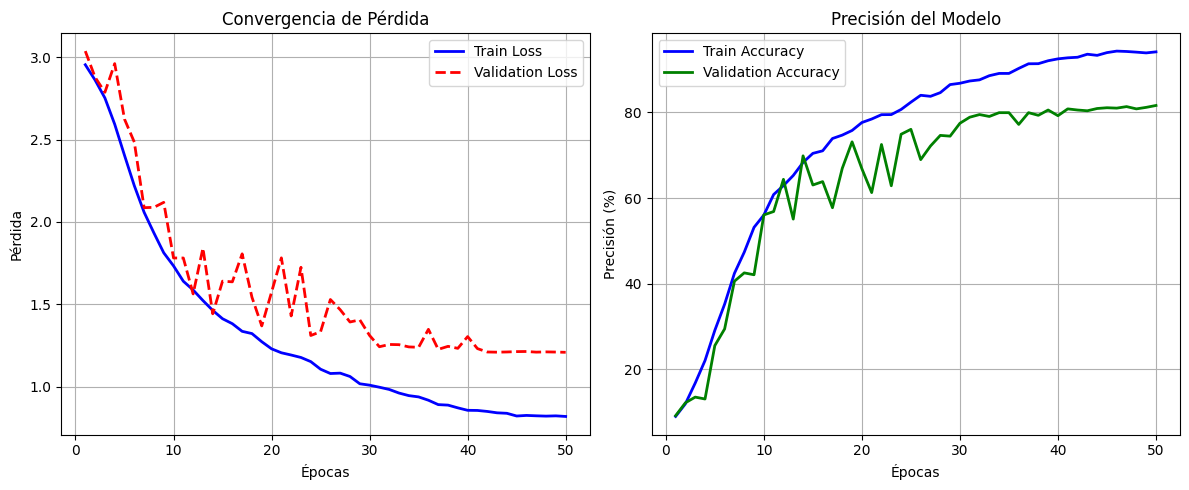


Listo. Mejor Val Loss: 1.2085 | Modelo en: /content/mejor_modelo_landmarks_conformer.pth


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Entrenando en: {device}')

MAX_FRAMES = 60
BATCH_SIZE = 32
VAL_RATIO = 0.2
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-3
EARLY_STOPPING_PATIENCE = 15
WARMUP_EPOCHS = 5
LABEL_SMOOTHING = 0.1

reference = LipReadingDataset(data_dir=DATASET_DIR, max_frames=MAX_FRAMES)
file_paths = reference.file_paths
num_classes = len(reference.class_names)
input_dim = reference.landmark_dim
print(f'Clases ({num_classes}): {reference.class_names}')
print(f'Dimensión de entrada detectada: {input_dim}')
print(f'Total muestras: {len(reference)}')

n = len(file_paths)
val_size = max(1, int(n * VAL_RATIO))
train_size = n - val_size
rng = np.random.default_rng(SEED)
indices = rng.permutation(n)
train_idx, val_idx = indices[:train_size], indices[train_size:]
train_paths = [file_paths[i] for i in train_idx]
val_paths = [file_paths[i] for i in val_idx]

train_dataset = LipReadingDataset(data_dir=DATASET_DIR, max_frames=MAX_FRAMES, file_paths=train_paths, augment=True)
val_dataset = LipReadingDataset(data_dir=DATASET_DIR, max_frames=MAX_FRAMES, file_paths=val_paths, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print(f'Train: {len(train_dataset)} (con aumento de datos) | Val: {len(val_dataset)} (sin aumento)')

model = LipReadingConformer(num_classes=num_classes, input_dim=input_dim).to(device)
# Label smoothing: en vez de pedirle al modelo 100% de confianza en la clase
# correcta, le pide un poco menos -- reduce sobreconfianza/sobreajuste, más
# notorio con muchas clases (57).
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = build_warmup_cosine_scheduler(optimizer, EPOCHS, WARMUP_EPOCHS)
early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, min_delta=0.001)


def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for sequences, labels, lengths in loader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)
            mask = make_padding_mask(lengths, sequences.shape[1], device)

            if train:
                optimizer.zero_grad()
            outputs = model(sequences, src_key_padding_mask=mask)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                # Gradient clipping: evita que los picos de gradiente típicos
                # de un Transformer/Conformer desde cero hagan "rebotar" la
                # pérdida en vez de converger.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * sequences.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total if total > 0 else 0.0
    acc = 100.0 * correct / total if total > 0 else 0.0
    return avg_loss, acc


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

print('\nIniciando entrenamiento (TCN + Conformer)...')
for epoch in range(EPOCHS):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    lr_actual = optimizer.param_groups[0]['lr']
    print(f'Época [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | LR: {lr_actual:.6f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': reference.class_names,
            'max_frames': MAX_FRAMES,
            'input_dim': input_dim,
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, MODEL_PATH)
        print(f'  -> Nuevo mejor modelo guardado (Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%)')

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f'  -> Early stopping activado en la época {epoch+1} (sin mejora en Val Loss por {EARLY_STOPPING_PATIENCE} épocas).')
        break

plot_training_curves(history['train_loss'], history['val_loss'], history['train_acc'], history['val_acc'])
print(f'\nListo. Mejor Val Loss: {best_val_loss:.4f} | Modelo en: {MODEL_PATH}')

## Resultados

**Muestras de validacion:** 1131

### Accuracy

- Top-1: **81.61%**
- Top-3: **92.04%**

### Matriz de confusion

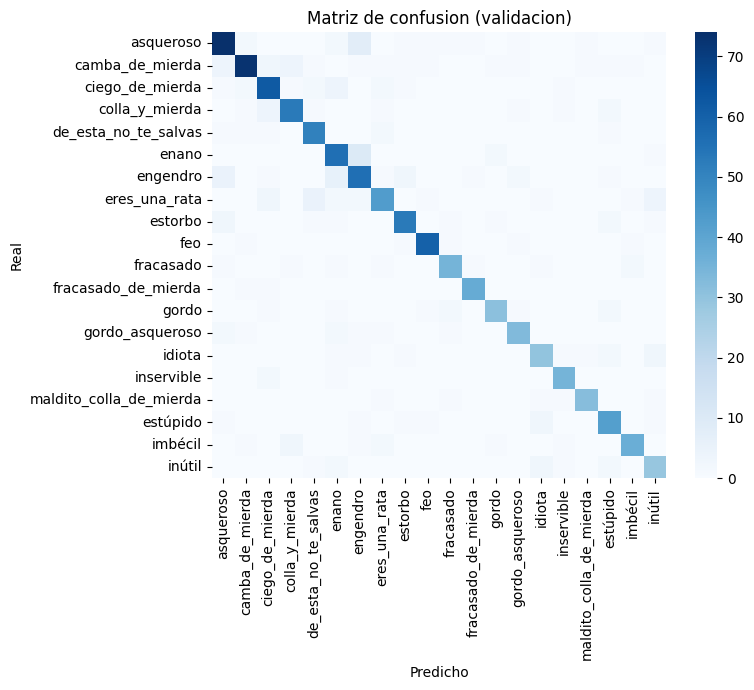

### Motor de riesgo (umbral 40%)

- Frases de riesgo detectadas correctamente: **1088/1131** (96.20%)
- Falsos negativos (riesgo real no detectado): **43** (3.80%)

*Nota: los falsos positivos todavia no se pueden medir -- falta un set de prueba con frases fuera del vocabulario entrenado.*

### Latencia de inferencia

- Promedio: **4.09 ms** (batch=1, cuda)

-> Reporte guardado: reporte_resultados.md


In [5]:
from sklearn.metrics import confusion_matrix
from IPython.display import display, Markdown
try:
    import seaborn as sns
except ImportError:
    sns = None
import time

# Cargamos el MEJOR checkpoint guardado (no el de la ultima epoca) antes
# de medir nada, para que el reporte refleje el mejor modelo.
best_checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels, all_top3_hit, all_top_probs = [], [], [], []
latencies_ms = []

with torch.no_grad():
    for sequences, labels, lengths in val_loader:
        sequences = sequences.to(device)
        lengths_dev = lengths.to(device)
        mask = make_padding_mask(lengths_dev, sequences.shape[1], device)

        outputs = model(sequences, src_key_padding_mask=mask)
        probs = torch.softmax(outputs, dim=1)

        top1 = probs.argmax(dim=1).cpu()
        top3 = probs.topk(min(3, probs.shape[1]), dim=1).indices.cpu()
        top_prob = probs.max(dim=1).values.cpu()

        all_preds.extend(top1.tolist())
        all_labels.extend(labels.tolist())
        all_top_probs.extend(top_prob.tolist())
        for i in range(labels.size(0)):
            all_top3_hit.append(labels[i].item() in top3[i].tolist())

        # Latencia real: una muestra a la vez (batch=1), como en la app real.
        for i in range(sequences.size(0)):
            start = time.perf_counter()
            _ = model(sequences[i:i+1], src_key_padding_mask=mask[i:i+1])
            latencies_ms.append((time.perf_counter() - start) * 1000)

total = len(all_labels)
class_names = reference.class_names
top1_acc = 100.0 * sum(p == l for p, l in zip(all_preds, all_labels)) / total
top3_acc = 100.0 * sum(all_top3_hit) / total

display(Markdown(f"## Resultados\n\n**Muestras de validacion:** {total}"))
display(Markdown(f"### Accuracy\n\n- Top-1: **{top1_acc:.2f}%**\n- Top-3: **{top3_acc:.2f}%**"))

# --- Matriz de confusion ---
display(Markdown("### Matriz de confusion"))
cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
plt.figure(figsize=(max(8, len(class_names) * 0.35), max(6, len(class_names) * 0.35)))
if sns is not None:
    sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap='Blues')
else:
    plt.imshow(cm, cmap='Blues')
    plt.xticks(range(len(class_names)), class_names)
    plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicho'); plt.ylabel('Real'); plt.title('Matriz de confusion (validacion)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'matriz_confusion.png'))
plt.show()

# --- Motor de riesgo (umbral 40%) ---
# Ojo: el set de validacion son todo frases DE RIESGO reales, no hay
# ejemplos negativos -- solo se puede medir el FALSO NEGATIVO (riesgo real
# no detectado). El FALSO POSITIVO necesita un set de prueba con frases
# fuera del vocabulario, que todavia no existe.
umbral = 0.40
detectadas = sum(1 for p in all_top_probs if p >= umbral)
no_detectadas = total - detectadas

display(Markdown(
    f"### Motor de riesgo (umbral {umbral*100:.0f}%)\n\n"
    f"- Frases de riesgo detectadas correctamente: **{detectadas}/{total}** "
    f"({100.0*detectadas/total:.2f}%)\n"
    f"- Falsos negativos (riesgo real no detectado): **{no_detectadas}** "
    f"({100.0*no_detectadas/total:.2f}%)\n\n"
    "*Nota: los falsos positivos todavia no se pueden medir -- falta un set "
    "de prueba con frases fuera del vocabulario entrenado.*"
))

# --- Latencia ---
avg_latency_ms = sum(latencies_ms) / len(latencies_ms)
display(Markdown(f"### Latencia de inferencia\n\n- Promedio: **{avg_latency_ms:.2f} ms** (batch=1, {device})"))

# Guardamos todo junto en un .md por si lo queres pegar en el informe.
reporte_md = (
    f"## Resultados\n\n**Muestras de validacion:** {total}\n\n"
    f"### Accuracy\n\n- Top-1: **{top1_acc:.2f}%**\n- Top-3: **{top3_acc:.2f}%**\n\n"
    "### Matriz de confusion\n\nGuardada en: `matriz_confusion.png`\n\n"
    f"### Motor de riesgo (umbral {umbral*100:.0f}%)\n\n"
    f"- Frases de riesgo detectadas correctamente: **{detectadas}/{total}** "
    f"({100.0*detectadas/total:.2f}%)\n"
    f"- Falsos negativos (riesgo real no detectado): **{no_detectadas}** "
    f"({100.0*no_detectadas/total:.2f}%)\n\n"
    "*Nota: los falsos positivos todavia no se pueden medir -- falta un set "
    "de prueba con frases fuera del vocabulario entrenado.*\n\n"
    f"### Latencia de inferencia\n\n- Promedio: **{avg_latency_ms:.2f} ms** (batch=1, {device})\n"
)
with open(os.path.join(BASE_DIR, 'reporte_resultados.md'), 'w', encoding='utf-8') as f:
    f.write(reporte_md)
print('-> Reporte guardado: reporte_resultados.md')


Al terminar, descargá `mejor_modelo_landmarks_conformer.pth` (Archivos > /content > click derecho > Descargar) y ponelo en `models/` de tu proyecto local.